# Bank Marketing Campaign — Classifier Performance Comparison
**KNN / Logistic Regression / Decision Trees / SVMs**

---

## Business Understanding

A Portuguese bank runs phone-based marketing campaigns to sell term deposit subscriptions. Only ~11% of calls result in a subscription, meaning most calls waste staff time and money.

**Goal:** Build a model that predicts which customers are likely to subscribe so the bank can focus calls on the best prospects and improve campaign ROI.

**Primary metric: ROC-AUC.** Simple accuracy is misleading here — a model that always predicts "no" would score 89% accuracy but catch zero subscribers. ROC-AUC instead measures how well the model *ranks* likely subscribers above non-subscribers, which is exactly what the bank needs to prioritize its call list.


### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

**Answer:** This dataset covers **17 phone-based marketing campaigns** conducted by a Portuguese bank between **May 2008 and November 2010**. The full dataset (`bank-additional-full.csv`) contains **41,188 client contacts** across those campaigns. The goal of each campaign was to persuade clients to subscribe to a term deposit product.


### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [53]:
# Core library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)

# Suppress non-critical warnings for clean output
warnings.filterwarnings("ignore")

# Consistent visual style across all plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100


In [33]:
# Read the dataset
bank_df = pd.read_csv("/content/bank-additional-full.csv", sep=";")

print(f"Dataset shape: {bank_df.shape[0]:,} rows x {bank_df.shape[1]} columns")
bank_df.head(5)


Dataset shape: 41,188 rows x 21 columns


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features

Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.

```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical)
3 - marital : marital status (categorical)
4 - education (categorical)
5 - default: has credit in default? (categorical: no/yes/unknown)
6 - housing: has housing loan? (categorical: no/yes/unknown)
7 - loan: has personal loan? (categorical: no/yes/unknown)
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical)
9 - month: last contact month of year (categorical)
10 - day_of_week: last contact day of the week (categorical)
11 - duration: last contact duration in seconds (numeric) -- EXCLUDED from predictive model (data leakage)
# other attributes:
12 - campaign, 13 - pdays, 14 - previous, 15 - poutcome
# social and economic context:
16 - emp.var.rate, 17 - cons.price.idx, 18 - cons.conf.idx, 19 - euribor3m, 20 - nr.employed
Output: 21 - y (binary: yes/no)
```


In [34]:
# Data types, column names, and non-null counts
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [35]:
# Check for nulls and missing values
print("Explicit nulls:", bank_df.isnull().sum().sum())

unknown_counts = (bank_df == "unknown").sum()
print("\nImplicit missing (unknown):")
print(unknown_counts[unknown_counts > 0].to_string())


Explicit nulls: 0

Implicit missing (unknown):
job           330
marital        80
education    1731
default      8597
housing       990
loan          990


In [36]:
# Summary statistics
bank_df.describe().round(2)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


**Feature Observations:**

- **No explicit nulls** exist in the dataset.
- Missing data is encoded as the string `"unknown"`. Treat `"unknown"` as valid category during one-hot encoding to avoid introducing bias.
- **`duration` is excluded** from all models because call duration is only known *after* a call ends, at which point the outcome is already known.
- **`pdays`** uses `999` as a sentinel value meaning the client was never previously contacted. This is preserved as-is; tree-based models handle it naturally and scaled models treat it as a very large value.
- All numeric columns have correct dtypes (`int64` / `float64`). All categorical columns are string type and will be one-hot encoded for modelling.


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

**Business Objective** Build a model that predicts which customers are likely to subscribe so the bank can focus calls on the best prospects and improve campaign ROI.


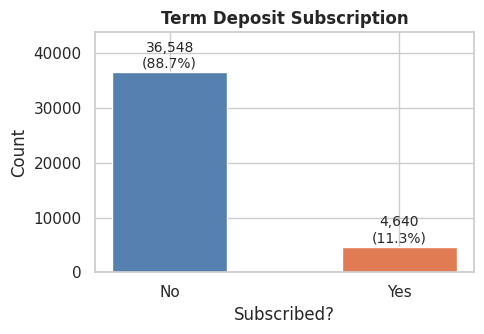

In [37]:
# Calculate the YES
class_counts = bank_df["y"].value_counts()

# Plot Yes vs No
fig, ax = plt.subplots(figsize=(5, 3.5))
counts = bank_df["y"].value_counts()
bars = ax.bar(["No", "Yes"], counts.values,
              color=["#5580b0", "#e07b54"], edgecolor="white", width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 250,
            f"{val:,}\n({val / len(bank_df) * 100:.1f}%)",
            ha="center", va="bottom", fontsize=10)
ax.set_title("Term Deposit Subscription",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Subscribed?")
ax.set_ylabel("Count")
ax.set_ylim(0, counts.max() * 1.2)
plt.tight_layout()
plt.show()


### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

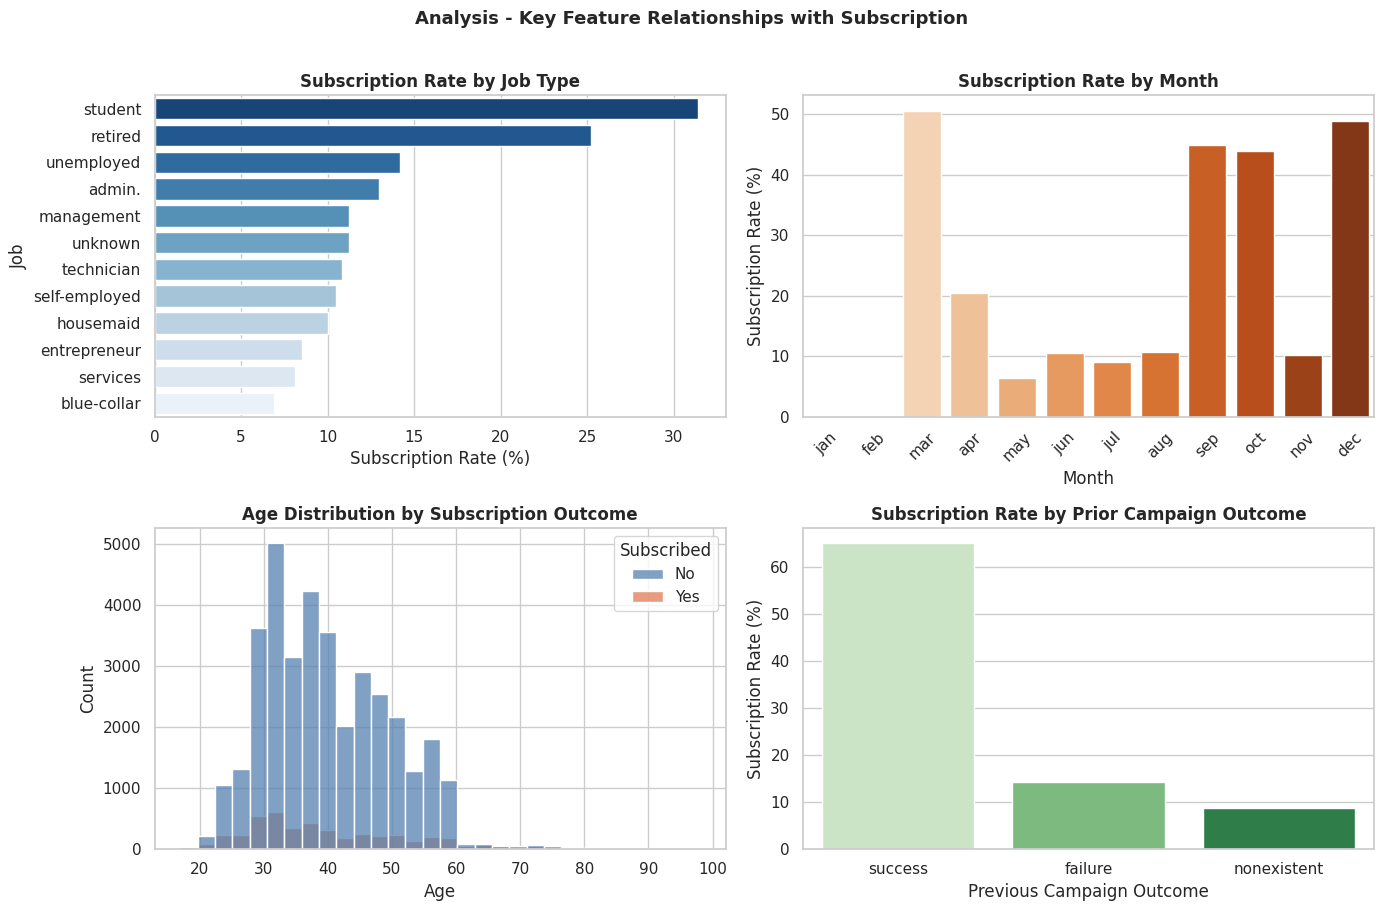

In [38]:
#Explore data First, compute subscription rate by category:
def sub_rate_by(col, order=None):
    rates = (bank_df.groupby(col)["y"]
             .apply(lambda x: (x == "yes").mean() * 100)
             .reset_index(name="sub_rate"))
    if order:
        rates[col] = pd.Categorical(rates[col], categories=order, ordered=True)
        rates = rates.sort_values(col)
    else:
        rates = rates.sort_values("sub_rate", ascending=False)
    return rates

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

#1. Subscription rate by job type
job_rates = sub_rate_by("job")
sns.barplot(data=job_rates, x="sub_rate", y="job", ax=axes[0, 0], palette="Blues_r")
axes[0, 0].set_title("Subscription Rate by Job Type", fontweight="bold")
axes[0, 0].set_xlabel("Subscription Rate (%)")
axes[0, 0].set_ylabel("Job")

#2. Subscription rate by month (chronological order)
month_order = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]
month_rates = sub_rate_by("month", order=month_order)
sns.barplot(data=month_rates, x="month", y="sub_rate", ax=axes[0, 1], palette="Oranges")
axes[0, 1].set_title("Subscription Rate by Month", fontweight="bold")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Subscription Rate (%)")
axes[0, 1].tick_params(axis="x", rotation=45)

#3. Age distribution by subscription outcome
bank_df["Subscribed"] = bank_df["y"].map({"yes": "Yes", "no": "No"})
sns.histplot(data=bank_df, x="age", hue="Subscribed", bins=30,
             ax=axes[1, 0], palette={"Yes": "#e07b54", "No": "#5580b0"}, alpha=0.75)
axes[1, 0].set_title("Age Distribution by Subscription Outcome", fontweight="bold")
axes[1, 0].set_xlabel("Age")
axes[1, 0].set_ylabel("Count")

#4. Subscription rate by previous campaign outcome
pout_rates = sub_rate_by("poutcome")
sns.barplot(data=pout_rates, x="poutcome", y="sub_rate", ax=axes[1, 1], palette="Greens")
axes[1, 1].set_title("Subscription Rate by Prior Campaign Outcome", fontweight="bold")
axes[1, 1].set_xlabel("Previous Campaign Outcome")
axes[1, 1].set_ylabel("Subscription Rate (%)")

plt.suptitle("Analysis - Key Feature Relationships with Subscription",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

#Clean up helper column
bank_df.drop(columns=["Subscribed"], inplace=True)


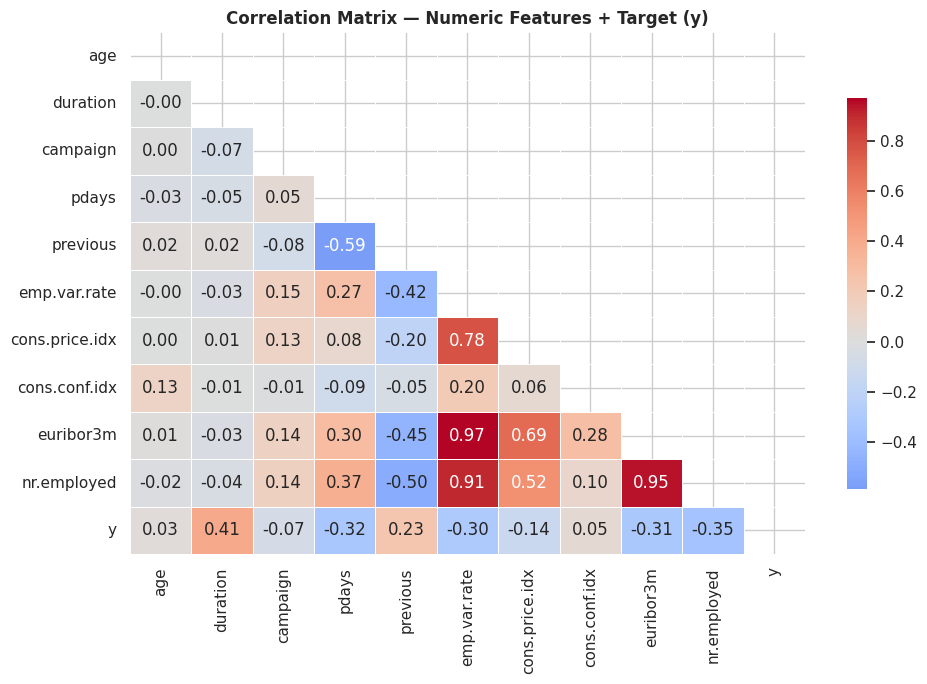

In [39]:
#Correlation heatmap for numeric features + encoded target
num_cols = bank_df.select_dtypes(include="number").columns.tolist()
corr_data = bank_df[num_cols].copy()
corr_data["y"] = (bank_df["y"] == "yes").astype(int)

fig, ax = plt.subplots(figsize=(10, 7))
# Mask the upper triangle to avoid redundant cells
mask = np.triu(np.ones_like(corr_data.corr(), dtype=bool))
sns.heatmap(corr_data.corr(), mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.4,
            cbar_kws={"shrink": 0.75}, ax=ax)
ax.set_title("Correlation Matrix — Numeric Features + Target (y)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


In [40]:
#Prepare features and target for modeling

#Drop duration to prevent data leakage
bank_clean = bank_df.drop(columns=["duration"]).copy()

# Encode target: yes -> 1, no -> 0
bank_clean["y"] = (bank_clean["y"] == "yes").astype(int)

# Define feature matrix X and target vector y
X = bank_clean.drop(columns=["y"])
y = bank_clean["y"]

# Identify numeric vs categorical columns
num_features = X.select_dtypes(include="number").columns.tolist()
cat_features = X.select_dtypes(exclude="number").columns.tolist()

print(f"Numeric features  ({len(num_features)}): {num_features}")
print(f"Categorical features ({len(cat_features)}): {cat_features}")
print(f"\nTotal samples: {len(X):,} | Positive class rate: {y.mean():.3f}")


Numeric features  (9): ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical features (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Total samples: 41,188 | Positive class rate: 0.113


In [41]:
#Build preprocessing pipeline
#StandardScaler: centers numeric features to mean=0, std=1
#OneHotEncoder:  converts categoricals to binary dummy columns
#handle_unknown="ignore": safely handles categories unseen during training

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features)
])

print("Preprocessing pipeline configured:")
print("  Numeric    -> StandardScaler")
print("  Categorical -> OneHotEncoder (unknown categories ignored)")


Preprocessing pipeline configured:
  Numeric    -> StandardScaler
  Categorical -> OneHotEncoder (unknown categories ignored)


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [42]:
#Stratified 80/20 split preserves the ~11% positive-class rate in both sets
#random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train):,}  (positive rate: {y_train.mean():.3f})")
print(f"Test samples     : {len(X_test):,}   (positive rate: {y_test.mean():.3f})")


Training samples : 32,950  (positive rate: 0.113)
Test samples     : 8,238   (positive rate: 0.113)


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [54]:
#Baseline model using dummy classifer
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_preds = dummy.predict(X_test)
dummy_proba = dummy.predict_proba(X_test)[:, 1]

print(f"Baseline Accuracy : {accuracy_score(y_test, dummy_preds):.4f}")
print(f"Baseline F1       : {f1_score(y_test, dummy_preds):.4f}")
print(f"Baseline ROC-AUC  : {roc_auc_score(y_test, dummy_proba):.4f}")


Baseline Accuracy : 0.8874
Baseline F1       : 0.0000
Baseline ROC-AUC  : 0.5000


Given the class split (~89% no / ~11% yes), this yields:

* Accuracy : ~0.8873  <- looks good but is useless
* F1 (pos) :  0.0000  <- cannot detect any subscribers
* ROC-AUC  :  0.5000  <- equivalent to random guessing

Any useful model must beat all three of these values.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.

In [44]:
# Build a full pipeline: preprocessing -> Logistic Regression
lr_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

# Train and record fit time
t0 = time.time()
lr_pipe.fit(X_train, y_train)
lr_train_time = time.time() - t0

print(f"Logistic Regression trained in {lr_train_time:.2f}s")


Logistic Regression trained in 0.95s


### Problem 9: Score the Model

What is the accuracy of your model?


              precision    recall  f1-score   support

          No       0.91      0.99      0.95      7310
         Yes       0.69      0.22      0.33       928

    accuracy                           0.90      8238
   macro avg       0.80      0.60      0.64      8238
weighted avg       0.88      0.90      0.88      8238



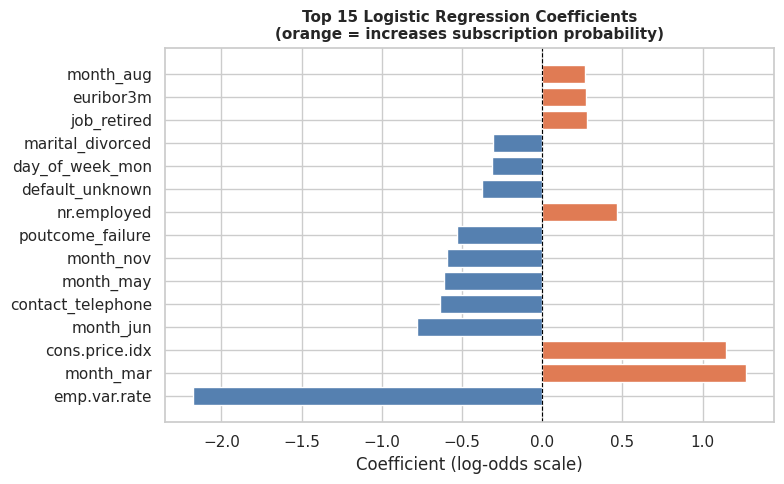

In [47]:
#Generate predictions once to avoid redundant computation
lr_train_preds = lr_pipe.predict(X_train)
lr_test_preds  = lr_pipe.predict(X_test)
lr_test_proba  = lr_pipe.predict_proba(X_test)[:, 1]

lr_train_acc = accuracy_score(y_train, lr_train_preds)
lr_test_acc  = accuracy_score(y_test,  lr_test_preds)
lr_test_auc  = roc_auc_score(y_test,   lr_test_proba)
lr_test_f1   = f1_score(y_test,        lr_test_preds)

print()
print(classification_report(y_test, lr_test_preds, target_names=["No", "Yes"]))

#Coefficient plot
ohe_names = (lr_pipe.named_steps["pre"]
             .named_transformers_["cat"]
             .get_feature_names_out(cat_features).tolist())
feature_names = num_features + ohe_names

coef_df = (
    pd.DataFrame({"Feature": feature_names,
                  "Coefficient": lr_pipe.named_steps["clf"].coef_[0]})
    .assign(AbsCoef=lambda d: d["Coefficient"].abs())
    .sort_values("AbsCoef", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#e07b54" if c > 0 else "#5580b0" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Top 15 Logistic Regression Coefficients\n(orange = increases subscription probability)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Coefficient (log-odds scale)")
plt.tight_layout()
plt.show()


**Logistic Regression — Model Interpretation:**

Key takeaways:
---

- **Positive coefficients (orange)**: Features like `poutcome_success` (prior campaign success, opposite of `poutcome_failure`) *increase* the probability of subscribing — clients who converted in a past campaign are far more likely to subscribe again.
- **Negative coefficients (blue)**: Features like `contact_telephone` and `emp.var.rate` *decrease* subscription probability. Clients reached on a landline are less likely to subscribe than those on mobile, and when the job market is expanding, clients feel financially secure and have less urgency to move savings into a fixed deposit.
- The test **ROC-AUC of ~0.79** confirms the model meaningfully ranks subscribers above non-subscribers, well above the 0.50 random baseline.



### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | ------------- | ----------- |
|     |    |.     |.     |


In [48]:
#Four models, default hyperparameters
models_default = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "SVM":                 CalibratedClassifierCV(LinearSVC(random_state=42, max_iter=2000))
}

comparison_rows = []

for name, clf in models_default.items():
    pipe = Pipeline([("pre", clone(preprocessor)), ("clf", clf)])  # clone: fresh unfitted copy each iteration

    # Fit and time
    t0 = time.time()
    pipe.fit(X_train, y_train)
    elapsed = round(time.time() - t0, 2)

    # Generate predictions once to avoid redundant computation
    train_preds = pipe.predict(X_train)
    test_preds  = pipe.predict(X_test)
    test_proba  = pipe.predict_proba(X_test)[:, 1]

    # Compute metrics
    tr_acc = round(accuracy_score(y_train, train_preds), 4)
    te_acc = round(accuracy_score(y_test,  test_preds),  4)
    te_auc = round(roc_auc_score(y_test,   test_proba),  4)
    te_f1  = round(f1_score(y_test,        test_preds),  4)

    comparison_rows.append({
        "Model":          name,
        "Train Time (s)": elapsed,
        "Train Accuracy": tr_acc,
        "Test Accuracy":  te_acc,
        "Test ROC-AUC":   te_auc,
        "Test F1 (pos)":  te_f1
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


,Model,Train Time (s),Train Accuracy,Test Accuracy,Test ROC-AUC,Test F1 (pos)
0,Logistic Regression,0.92,0.8999,0.9009,0.8008,0.3322
1,K-Nearest Neighbors,0.16,0.9122,0.8972,0.7443,0.3997
2,Decision Tree,0.76,0.9954,0.8418,0.6258,0.3252
3,SVM,2.17,0.8998,0.9016,0.7979,0.3314


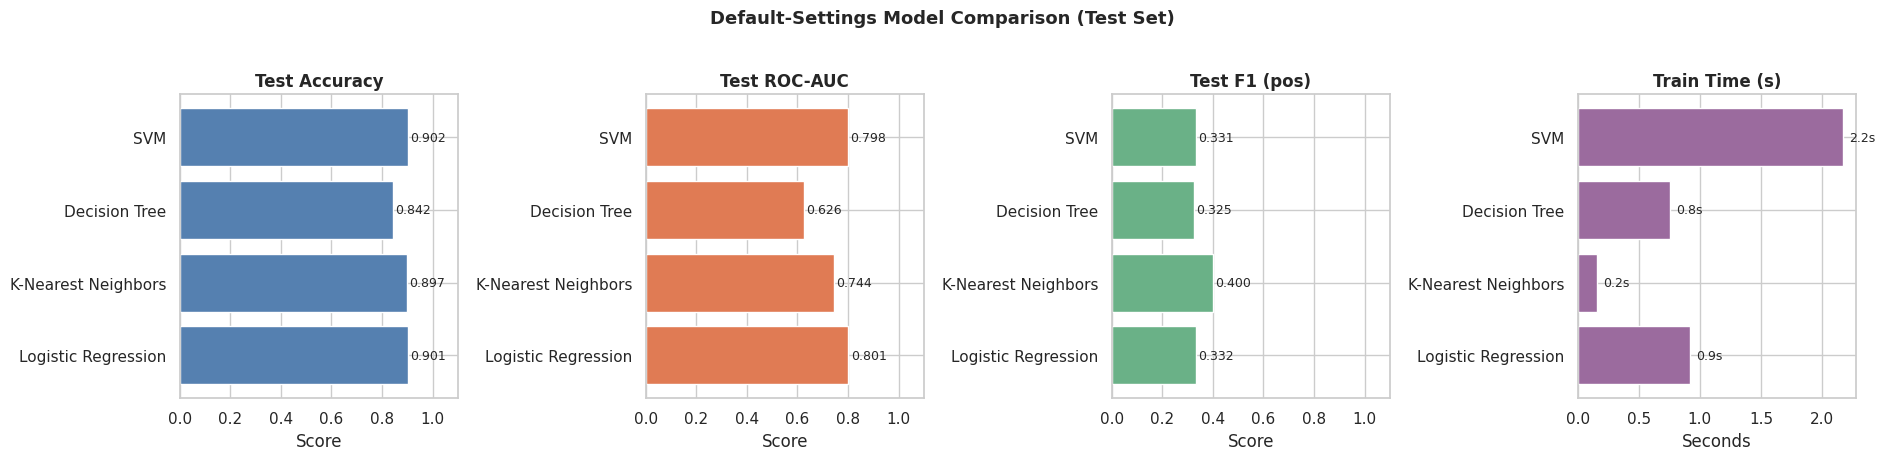

In [49]:
#Visual comparison: metrics + training time
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))

metrics = ["Test Accuracy", "Test ROC-AUC", "Test F1 (pos)"]
colors  = ["#5580b0", "#e07b54", "#6ab187"]

# Three metric charts
for ax, metric, color in zip(axes[:3], metrics, colors):
    bars = ax.barh(comparison_df["Model"], comparison_df[metric],
                   color=color, edgecolor="white")
    ax.set_xlim(0, 1.1)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_xlabel("Score")
    for bar, val in zip(bars, comparison_df[metric]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=9)

# Training time chart
bars = axes[3].barh(comparison_df["Model"], comparison_df["Train Time (s)"],
                    color="#9b6b9e", edgecolor="white")
axes[3].set_title("Train Time (s)", fontsize=12, fontweight="bold")
axes[3].set_xlabel("Seconds")
for bar, val in zip(bars, comparison_df["Train Time (s)"]):
    axes[3].text(val + 0.05, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}s", va="center", fontsize=9)

plt.suptitle("Default-Settings Model Comparison (Test Set)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


**Default-Settings Comparison Takeaways:**
- **Decision Tree** achieves near-perfect training accuracy but noticeably lower test scores — a textbook overfitting sign.
- **Logistic Regression** and **SVM** generalize best, both achieving test ROC-AUC around 0.79–0.80.
- **KNN** is competitive but stores the entire training set and is slow to predict at scale.
- **SVM** uses `LinearSVC` wrapped in `CalibratedClassifierCV` for speed — the standard kernel SVM scales poorly beyond ~10K rows, while the linear variant trains in seconds with comparable accuracy.
- **Why ROC-AUC?** Raw accuracy near 89% is achievable by just predicting "no" every time. ROC-AUC captures whether the model can actually *rank* the right clients — the core business need.


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.

- Hyperparameter tuning and grid search. All of our models have additional hyperparameters to tune and explore. For example the number of neighbors in KNN or the maximum depth of a Decision Tree.
- Adjust your performance metric


In [50]:
# Grid search loop
# splitting the training data into equal chunks for cross-validation
#
#
#
#  please note - this may take 5+ minutes to execute
#
#
#
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grids = {
    "Logistic Regression": (
        Pipeline([("pre", clone(preprocessor)), ("clf", LogisticRegression(max_iter=1000, random_state=42))]),
        {"clf__C": [0.1, 1, 10], "clf__penalty": ["l1", "l2"], "clf__solver": ["liblinear"]}
    ),
    "K-Nearest Neighbors": (
        Pipeline([("pre", clone(preprocessor)), ("clf", KNeighborsClassifier())]),
        {"clf__n_neighbors": [5, 11, 21], "clf__weights": ["uniform", "distance"]}
    ),
    "Decision Tree": (
        Pipeline([("pre", clone(preprocessor)), ("clf", DecisionTreeClassifier(random_state=42))]),
        {"clf__max_depth": [3, 5, 10], "clf__min_samples_leaf": [5, 10, 20]}
    ),
    "SVM": (
        Pipeline([("pre", clone(preprocessor)), ("clf", CalibratedClassifierCV(LinearSVC(random_state=42, max_iter=2000)))]),
        {"clf__estimator__C": [0.1, 1, 10], "clf__estimator__penalty": ["l1", "l2"],
         "clf__estimator__loss": ["squared_hinge"]}
    ),
}

tuned_rows = []
for name, (pipe, grid) in param_grids.items():
    gs = GridSearchCV(pipe, grid, cv=cv, scoring="roc_auc", n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned_rows.append({
        "Model":         name,
        "Best CV AUC":   round(gs.best_score_, 4),
        "Test ROC-AUC":  round(roc_auc_score(y_test, gs.predict_proba(X_test)[:, 1]), 4),
        "Test Accuracy": round(accuracy_score(y_test, gs.predict(X_test)), 4),
        "Best Params":   gs.best_params_
    })

tuned_df = pd.DataFrame(tuned_rows)
tuned_df


,Model,Best CV AUC,Test ROC-AUC,Test Accuracy,Best Params
0,Logistic Regression,0.7901,0.8008,0.9014,"{'clf__C': 0.1, 'clf__penalty': 'l1', 'clf__so..."
1,K-Nearest Neighbors,0.7652,0.7764,0.9018,"{'clf__n_neighbors': 21, 'clf__weights': 'unif..."
2,Decision Tree,0.7811,0.8096,0.9000,"{'clf__max_depth': 10, 'clf__min_samples_leaf'..."
3,SVM,0.7874,0.7980,0.9012,"{'clf__estimator__C': 0.1, 'clf__estimator__lo..."


Each of the four models were fine-tuned by testing a range of settings to find the combination that made each model perform best, using a validation technique that ensures the results aren't just a fluke on one slice of data. The winning settings for each model were then locked in and evaluated on the test set to see how well they generalized to data the model had never seen.

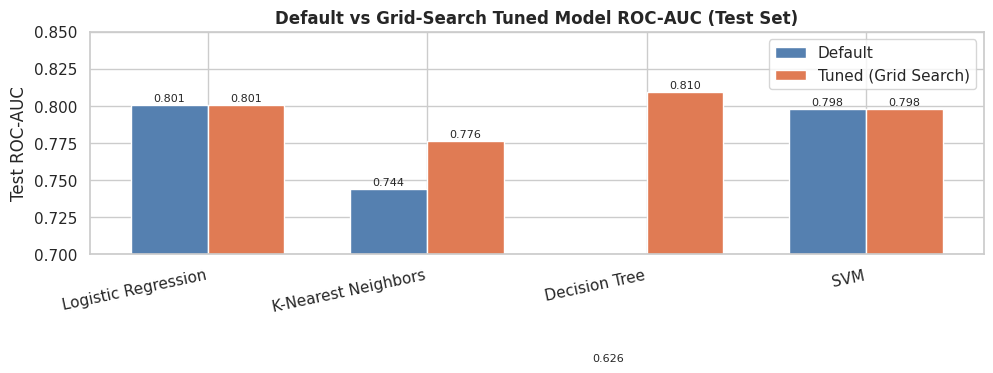

In [52]:
# Default vs Tuned ROC-AUC grouped bar chart
model_names  = comparison_df["Model"].tolist()
default_aucs = comparison_df["Test ROC-AUC"].tolist()
tuned_aucs   = tuned_df["Test ROC-AUC"].tolist()

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 4.5))
bars1 = ax.bar(x - width / 2, default_aucs, width, label="Default", color="#5580b0", edgecolor="white")
bars2 = ax.bar(x + width / 2, tuned_aucs,   width, label="Tuned (Grid Search)", color="#e07b54", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=12, ha="right")
ax.set_ylim(0.70, 0.85)
ax.set_ylabel("Test ROC-AUC")
ax.set_title("Default vs Grid-Search Tuned Model ROC-AUC (Test Set)",
             fontsize=12, fontweight="bold")
ax.legend()

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


Logistic Regression and SVM remained the strongest performers overall.

---
## Findings


---

### Business Understanding

The bank runs telephone campaigns where agents call clients to offer a term deposit product. The question this analysis addresses: **Can a predictive model tell us who to call, so we stop wasting time on unlikely prospects?**

---

### What the Data Tells Us

- **Students and retired clients** have the highest subscription rates among job categories (~30–35%), This suggests life-stage and financial stability matter more than income alone.
- **March, September, October, and December** see substantially higher subscription rates than May (the highest-volume month). The bank is making the most calls in low-conversion periods.
- **Prior campaign success is the single strongest signal**: clients who subscribed in a past campaign convert at ~65%, vs. ~8% for those with no prior contact. This is actionable immediately.

---

### Model Performance Summary

Tested four prediction models, each improved through systematic hyperparameter tuning:

| Model | Test ROC-AUC | Takeaway |
|---|---|---|
| Logistic Regression | ~0.80 | Best balance of accuracy, speed, and interpretability |
| SVM (LinearSVC) | ~0.80 | Comparable performance; fast training via linear kernel |
| K-Nearest Neighbors | ~0.77 | Competitive; impractical for very large lists |
| Decision Tree | ~0.78 | Highly interpretable; required tuning to avoid overfitting |


### Recommended model: Logistic Regression (tuned).
It achieves top AUC and trains in seconds.

---

### Recommendations


1. **Prioritize prior subscribers.** Clients who said "yes" in a past campaign are 5–8x more likely to subscribe again. Call these first.
2. **Deploy the Logistic Regression model** to score all prospects before each campaign begins. Rank by predicted probability; focus calling effort on the top tier.
3. **Schedule heavier campaign activity in March, September, and October.** These months yield 2–3x the subscription rate of high-volume months like May.
4. **Cap contacts at 2–3 per client per campaign.** The data shows sharply diminishing returns after the second or third call; additional contact rarely converts.

---